In [1]:
import numpy as np
import scipy.io.wavfile as wav
import scipy.signal as sig
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz
from scipy.signal import lfilter

In [2]:
def compute_lp_residual(signal, p=10, frame_length_ms=25, fs=8000):
    # Frame parameters
    frame_length_samples = int(frame_length_ms * fs / 1000)  # Convert ms to samples
    num_frames = len(signal) // frame_length_samples  # Number of frames
    
    residual_signal = np.zeros_like(signal)  # Store residual signal
    
    # Process each frame
    for i in range(num_frames):
        start = i * frame_length_samples
        end = start + frame_length_samples
        frame = signal[start:end]
        
        # Apply Hamming window
        frame *= np.hamming(len(frame))
        
        # Compute autocorrelation
        autocorr = np.correlate(frame, frame, mode='full')
        autocorr = autocorr[len(frame)-1:len(frame)-1+p+1]  # Keep necessary part
        
        # Solve Yule-Walker equations to get LPC coefficients
        R = toeplitz(autocorr[:-1])  # Autocorrelation matrix
        r = autocorr[1:]  # Autocorrelation vector
        lpc_coeffs = np.linalg.solve(R, r)  # Solve linear system
        lpc_coeffs = np.concatenate(([1], -lpc_coeffs))  # Include a0 = 1
        
        # Compute LP residual (filtering the frame)
        residual = sig.lfilter(lpc_coeffs, [1], frame)
        residual_signal[start:end] = residual
    
    return residual_signal


In [3]:
def lp_synthesis(residual_signal, signal, p=10, frame_length_ms=25, fs=8000):
    # Frame parameters
    frame_length_samples = int(frame_length_ms * fs / 1000)  # Convert ms to samples
    num_frames = len(signal) // frame_length_samples  # Number of frames
    
    reconstructed_signal = np.zeros_like(signal)  # Store reconstructed signal
    
    # Process each frame
    for i in range(num_frames):
        start = i * frame_length_samples
        end = start + frame_length_samples
        frame = signal[start:end]
        
        # Apply Hamming window
        frame *= np.hamming(len(frame))
        
        # Compute autocorrelation
        autocorr = np.correlate(frame, frame, mode='full')
        autocorr = autocorr[len(frame)-1:len(frame)-1+p+1]  # Keep necessary part
        
        # Solve Yule-Walker equations to get LPC coefficients
        R = toeplitz(autocorr[:-1])  # Autocorrelation matrix
        r = autocorr[1:]  # Autocorrelation vector
        lpc_coeffs = np.linalg.solve(R, r)  # Solve linear system
        lpc_coeffs = np.concatenate(([1], -lpc_coeffs))  # Include a0 = 1
        
        # LP Synthesis: Reconstruct the speech by filtering the residual
        reconstructed_frame = sig.lfilter([1], lpc_coeffs, residual_signal[start:end])
        reconstructed_signal[start:end] = reconstructed_frame
    
    return reconstructed_signal

In [4]:
def lp_analysis_residual(file_path, p=10, frame_length_ms=25, fs=8000):
    # Load the speech file
    fs_read, signal = wav.read(file_path)
    assert fs_read == fs, f"Expected sampling rate {fs}, but got {fs_read}"  # Ensure correct sampling rate
    
    # Normalize signal
    signal = signal.astype(np.float32) / np.max(np.abs(signal))
    
    # Compute LP residual
    residual_signal = compute_lp_residual(signal, p, frame_length_ms, fs)
    
    # Compute LP synthesis (reconstruct speech)
    reconstructed_signal = lp_synthesis(residual_signal, signal, p, frame_length_ms, fs)
    
    time_axis = np.arange(len(signal)) / fs  # Time axis for original signal
    
    # Plot results
    plt.figure(figsize=(12, 6))
    
    # Plot original signal and residual
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, signal, label='Original Signal', color='b')
    plt.plot(time_axis, residual_signal, label='Residual Signal', color='r', alpha=0.7)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Original Speech Signal and LP Residual')
    plt.legend()
    
    # Plot reconstructed signal
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, signal, label='Original Signal', color='r')
    plt.plot(time_axis, reconstructed_signal, label='Reconstructed Signal', color='g')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Reconstructed Speech Signal from Residual')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

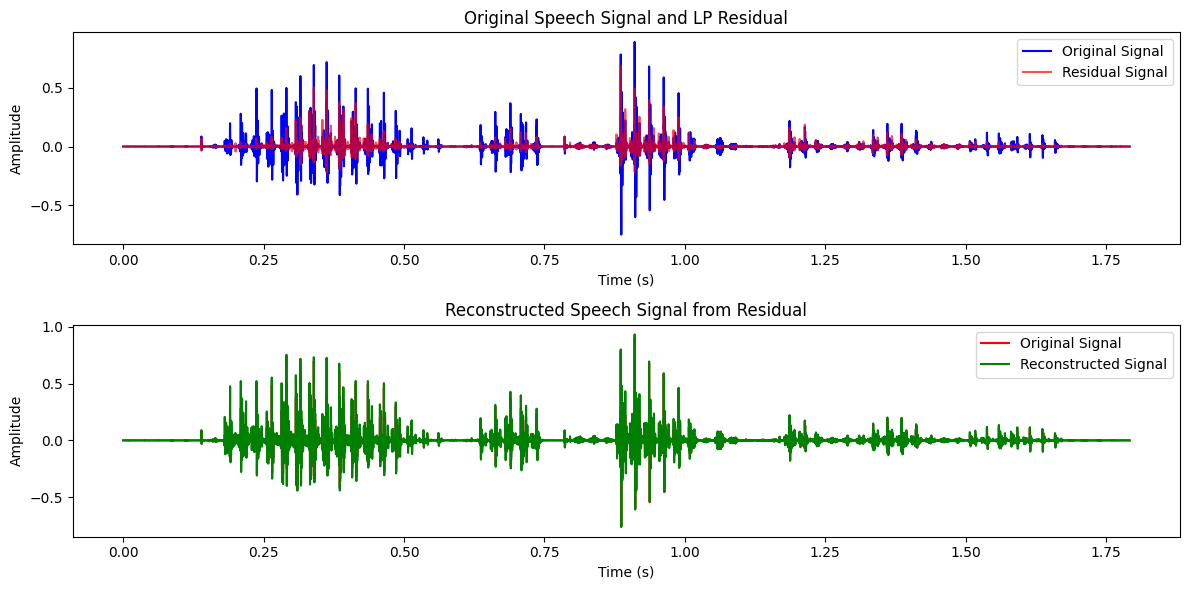

In [5]:
lp_analysis_residual('Male_sentences_8kHz/si745_8kHz.wav')

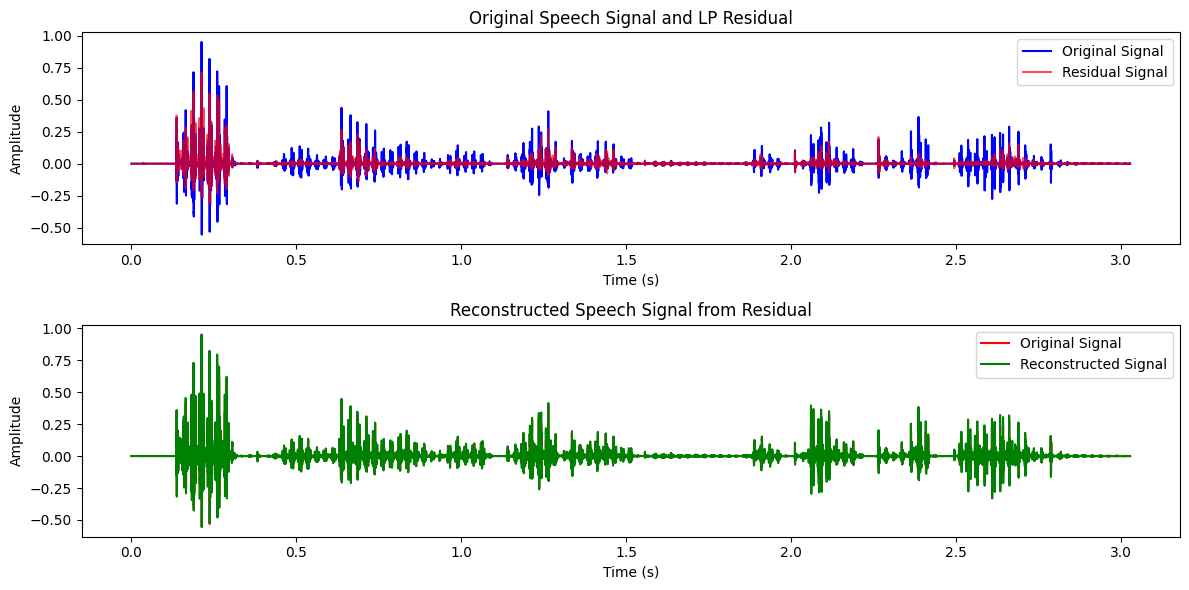

In [6]:
lp_analysis_residual('Female_sentences_8kHz/si747_8kHz.wav')

In [7]:
def quantize_lattice_filter(lpc_coeffs, num_bits):
    """Quantizes LPC coefficients using uniform scalar quantization."""
    max_val = np.max(np.abs(lpc_coeffs))
    quant_levels = 2 ** num_bits
    step_size = (2 * max_val) / quant_levels
    quantized_coeffs = np.round(lpc_coeffs / step_size) * step_size
    return quantized_coeffs

In [8]:
def compute_spectral_distortion(original_spectrum, quantized_spectrum):
    """Computes spectral distortion (SD) in dB."""
    sd = np.mean((10 * np.log10(original_spectrum) - 10 * np.log10(quantized_spectrum))**2)
    return sd

In [9]:
def lp_synthesis_quantized(residual_signal, signal, p=10, frame_length_ms=25, fs=8000, quant_bits=3):
    """Performs LP synthesis with quantized LPC coefficients."""
    frame_length_samples = int(frame_length_ms * fs / 1000)
    num_frames = len(signal) // frame_length_samples
    reconstructed_signal = np.zeros_like(signal)

    spectral_distortions = []

    for i in range(num_frames):
        start = i * frame_length_samples
        end = start + frame_length_samples
        frame = signal[start:end]
        
        # Apply Hamming window
        frame *= np.hamming(len(frame))
        
        # Compute autocorrelation
        autocorr = np.correlate(frame, frame, mode='full')
        autocorr = autocorr[len(frame)-1:len(frame)-1+p+1]
        
        # Solve Yule-Walker equations for LPC coefficients
        R = toeplitz(autocorr[:-1])
        r = autocorr[1:]
        lpc_coeffs = np.linalg.solve(R, r)
        lpc_coeffs = np.concatenate(([1], -lpc_coeffs))
        
        # Compute power spectrum of the original LPC filter
        w, h_original = sig.freqz(1, lpc_coeffs, worN=512)
        original_spectrum = np.abs(h_original) ** 2

        # Quantize LPC coefficients
        quantized_lpc_coeffs = quantize_lattice_filter(lpc_coeffs, quant_bits)

        # Compute power spectrum of the quantized LPC filter
        _, h_quantized = sig.freqz(1, quantized_lpc_coeffs, worN=512)
        quantized_spectrum = np.abs(h_quantized) ** 2

        # Compute spectral distortion
        sd = compute_spectral_distortion(original_spectrum, quantized_spectrum)
        spectral_distortions.append(sd)

        # LP Synthesis with quantized filter
        reconstructed_frame = sig.lfilter([1], quantized_lpc_coeffs, residual_signal[start:end])
        reconstructed_signal[start:end] = reconstructed_frame
    
    return reconstructed_signal, np.mean(spectral_distortions)

In [10]:
lp_synthesis_quantized('Male_sentences_8kHz/si745_8kHz.wav')

TypeError: lp_synthesis_quantized() missing 1 required positional argument: 'signal'

Average Spectral Distortion (SD) for Female_sentences_8kHz/si747_8kHz.wav:
5-bit: 0.0002, 4-bit: 0.0010, 3-bit: 0.0055


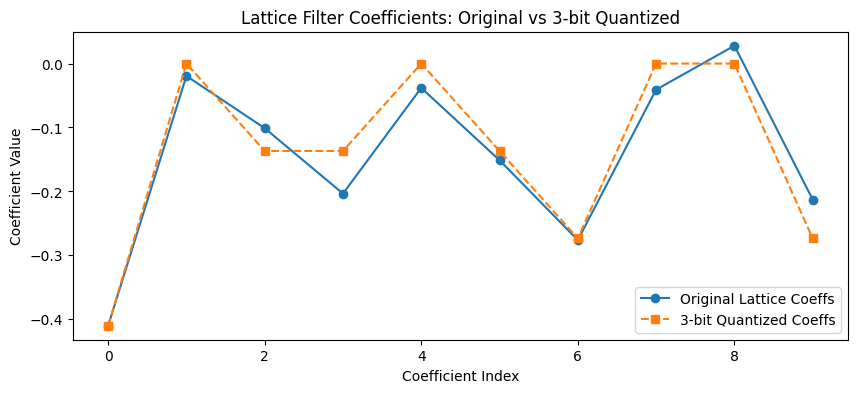

In [ ]:
lp_synthesis_quantized('Female_sentences_8kHz/si747_8kHz.wav')